# Data Processing

To prevent biases in downstream analyses due to highly similar sequences, sequence clustering was performed. This process grouped sequences based on their similarity, allowing the selection of representative sequences from each cluster.

## Sequence Clustering

First, the protein sequences extracted from the PDB was formatted into FASTA files, a standard format for biological sequences. Subsequently, using `MMseqs2`, a fast and sensitive sequence search and clustering suite, clusters were generated and a representative sequence for each was selected. `MMseqs2` will identify redundant sequences and group them, providing a non-redundant set for further analysis. This step is crucial for building a robust HMM that accurately captures the characteristics of the Kunitz domain family.

In [ ]:
import pandas as pd
import requests      # Import requests for HTTP requests to the PDB API
from pathlib import Path

In [8]:
data_path = Path("..") / "01_DataCollection" / "Files" / "df_pdb.tsv"
df_pdb = pd.read_csv(data_path, sep="\t")

# creating a Fasta file with the sequences and the PDB ids as headers
with open('Files/sequences_kd.fasta', 'w') as f:
    for i in range(df_pdb.shape[0]):
        f.write('>' + df_pdb['PDB_ID'][i] + '\n')
        f.write(df_pdb['Sequence'][i] + '\n')

`MMseqs` version 18.8cc5c was used. First of all, a database call `sequences_kdDB` was build from the previous `sequence_kd.fasta` file. The clusterization was set to have a minimal identity of 95% and an coverage of 85%. The representatives sequence were there selected by the program and save as tsv in the file `representative_seq.fasta`, available in the `Files` folder

```bash
# Create a database from the FASTA file using mmseqs2.
! mmseqs createdb sequences_kd.fasta sequences_kdDB

# Clustering the sequences
! mmseqs cluster sequences_kdDB cluster_kdDB tmp --min-seq-id 0.95 -c 0.85 --cov-mode 2

# Saving the cluster in a tsv file
! mmseqs createtsv sequences_kdDB sequences_kdDB cluster_kdDB cluster.tsv

# Counting how many cluster where made (20 clusters)
! cut -f1 cluster.tsv | sort | uniq | wc -l

# Retrieve the representative sequences of each cluster and store them in a new database.
! mmseqs createsubdb cluster_kdDB sequences_kdDB representative_seqDB

# Convert the mmseqs2 database of representative sequences to a FASTA file.
! mmseqs convert2fasta representative_seqDB representative_seq.fasta
```

## Structural Alignment

Having obtained a set of representative sequences through MMseqs2 clustering, the next phase involved retrieving their corresponding structural information and preparing them for alignment for understanding the conserved features within the Kunitz domain family.

### Parsing Representative Sequences
The FASTA of the representative sequences was parse to extract the unique PDB IDs of these sequences and then retrieve the structural configuration of the CIF file. 

In [12]:
# reading IDs of representative sequences from the FASTA file
representative_sequences = []
with open('Files/representative_seq.fasta', "r", encoding="utf-8") as f:
    for line in f:
        if line.startswith(">"):
            representative_sequences.append(line[1:].strip()) # to exclude the '>'

### Structural alignment files

For each identified PDB ID, the CIF file was downloaded from the PDB. These files contained detailed atomic coordinates and experimental data for the protein structures.

However, PDB entries can sometimes contain multiple protein chains, so based on the `Chain` information stored in the DataFrame (`df_pdb`), only the relevant chain(s) from each downloaded CIF file was retrieve.

In [25]:
# Downloading the cif files
for i in representative_sequences:
    url = f"https://files.rcsb.org/download/{i}.pdb"
    r = requests.get(url)
    with open(f"Files/CIF/{i}.pdb", 'wb') as f:
        f.write(r.content)

# Extracting the chain
for i in representative_sequences:    # parse a PDB file (open file and extract position for every atom)
    pdb_line = []
    chain = df_pdb.query('PDB_ID ==@i')['Chain'].iloc[0]
    with open(f"Files/CIF/{i}.pdb", 'r') as f:
        for line in f:
            if line.find ("ATOM") != 0 :       # select lines with "ATOMS"
                continue
            if line[21] != chain:              # Just select chain that matches the input
                continue
            pdb_line.append(line.rstrip())

    #create a new file with list of the accession numbers
    with open("Files/structural_alg.txt", "a") as f:
        f.write(f"{i}_{chain}.pdb" + "\n")
    
    # create a new file with the correct chain information
    name = f"Files/Structural_files/{i}_{chain}.pdb"
    with open(name, "w", encoding="utf-8") as f:
        for ele in pdb_line:
            f.write(ele + "\n")

### Structural Alignment

Finally, the extracted protein chains were structural align.
Two methods were evaluated:
*   `PDBe-Fold`: This online service, provided by the Protein Data Bank in Europe (PDBe), offers robust structural alignment functionalities. It is a reliable tool for comparing protein structures.
*   `mtm_alignment` (Version 20220104): This refers to a Multiple-sequence/structure-based Target-ligand Modeling alignment approach, often employed for aligning protein structures, particularly in the context of ligand binding.

Exploring both `PDBe-Fold` and `mtm_alignment` provides a more robust approach to structural alignment. While PDBe-Fold is powerful, it can sometimes experience delays or server unavailability. Having an alternative like mtm_alignment ensures that structural comparisons can proceed even if one service is temporarily inaccessible, maintaining the continuity of the workflow.

```bash
mtm-align -i structural_alg.txt
```

The multiple sequence aligment derive from the structural aligment from both PDBe-Fold (`pdbe_structural_alg`) and mtm_aligment (`mtm_structural_alg`) are available on the folder `alignments`.

For assessing the results, the alignments were inspected with `NCBI MSA Viewer`:

- PDBe-Fold Multiple sequence aligment:
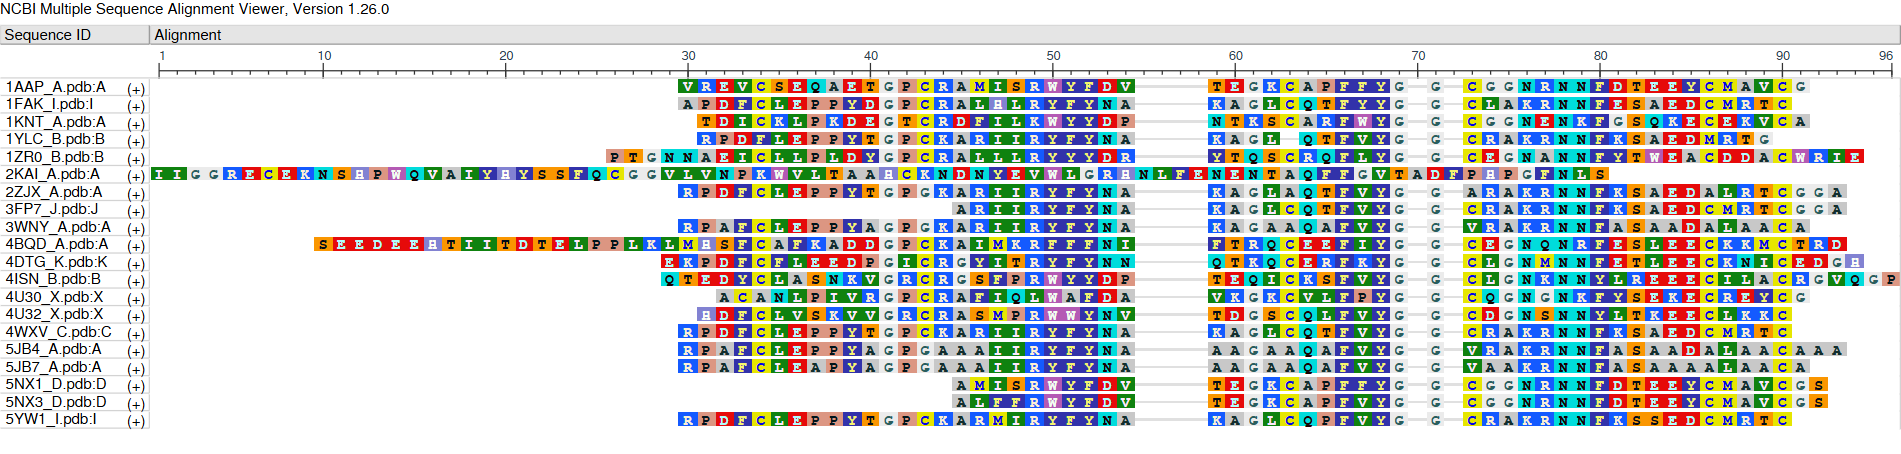

- mtm-alignment Multiple sequence aligment:
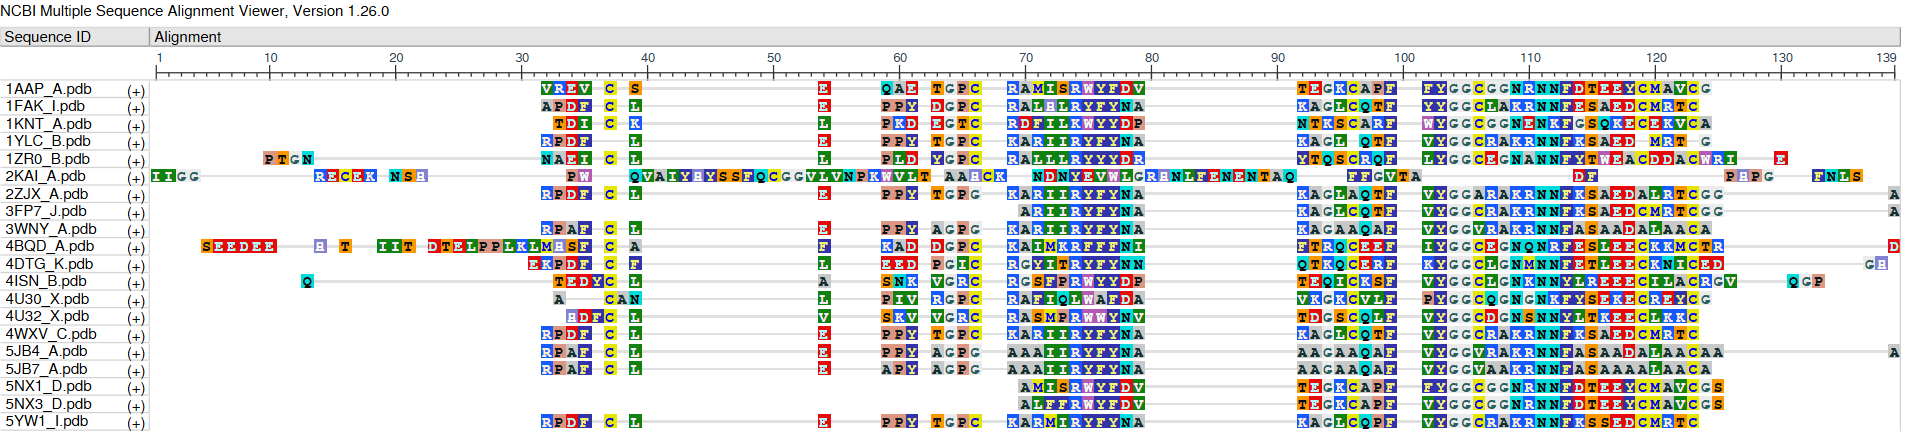

### Problematic sequence filtering

Based on both sequence and structural alignments, problematic entries such as `2KAI_A.pdb` and `4BQD_A.pdb` were identified and subsequently removed. These entries exhibited initial sections that did not correspond to homologous regions in other sequences, which could introduce inaccuracies into the alignment. 

Additionally, to ensure a uniform length across all sequences for consistent HMM building, the sequences were truncated to a length of 139 residues.

In [32]:
# filtering long sequences
def filter_problematic_seq(input_file):
    with open(input_file, 'r') as infile, open(f"alignments/filter_{input_file.split('/')[-1]}.fasta", 'w') as outfile:
        for line in infile:
            line = line.rstrip('\n')
            if line.startswith('>'):
                outfile.write(line.rstrip()+'\n')
                continue
            if len(line) > 139:
                line = line[0:139]
            outfile.write(line.rstrip() + '\n')
    return f"alignments/filter_{input_file.split('/')[-1]}.fasta"

filter_problematic_seq('alignments/mtm_structural_alg.fasta')
filter_problematic_seq('alignments/pdbe_structural_alg.fasta')

'alignments/filter_pdbe_structural_alg.fasta.fasta'

### Structural evaluation  

The sequence logos of both multiple sequence alignments were computed with `Skyling`. The mtm-based aligment was selected due to superior conservation of cysteine residues, which are characteristic of the Kunitz domain fold.

- PDBe-Fold-alignment sequence logo:
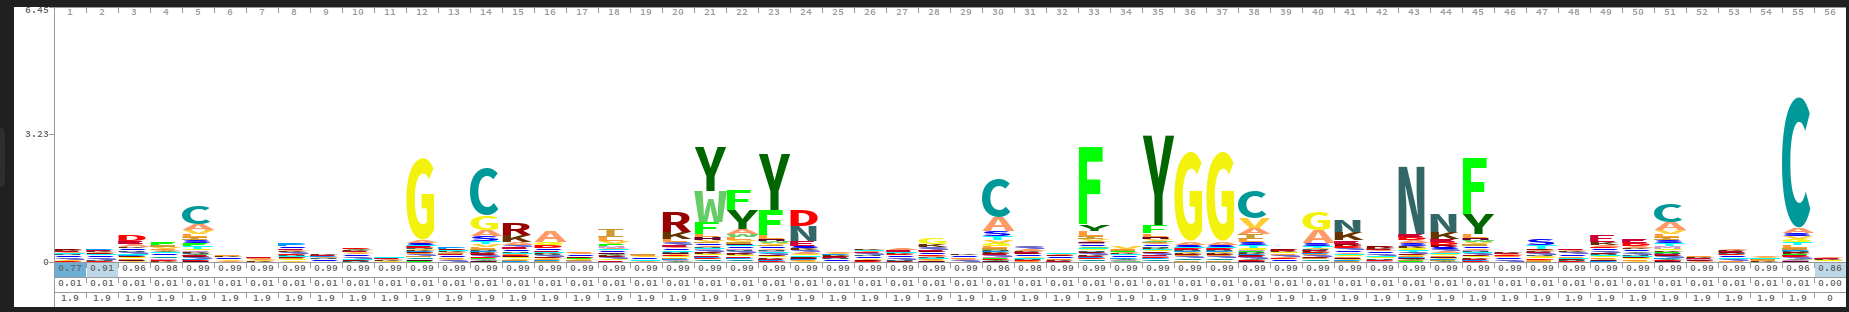

- mtm-alignment sequence logo:
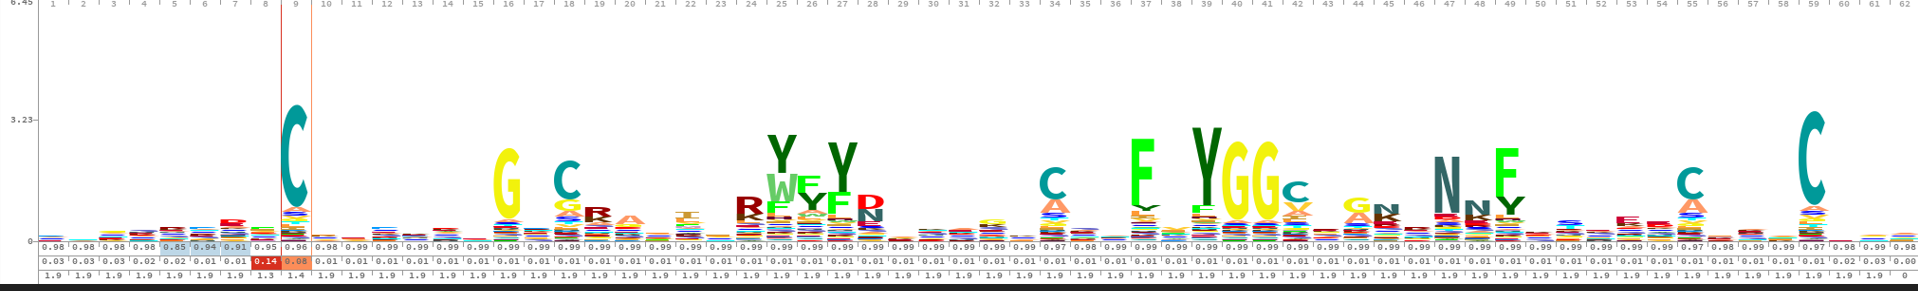


The structural aligment of mtm-align was also visualize 

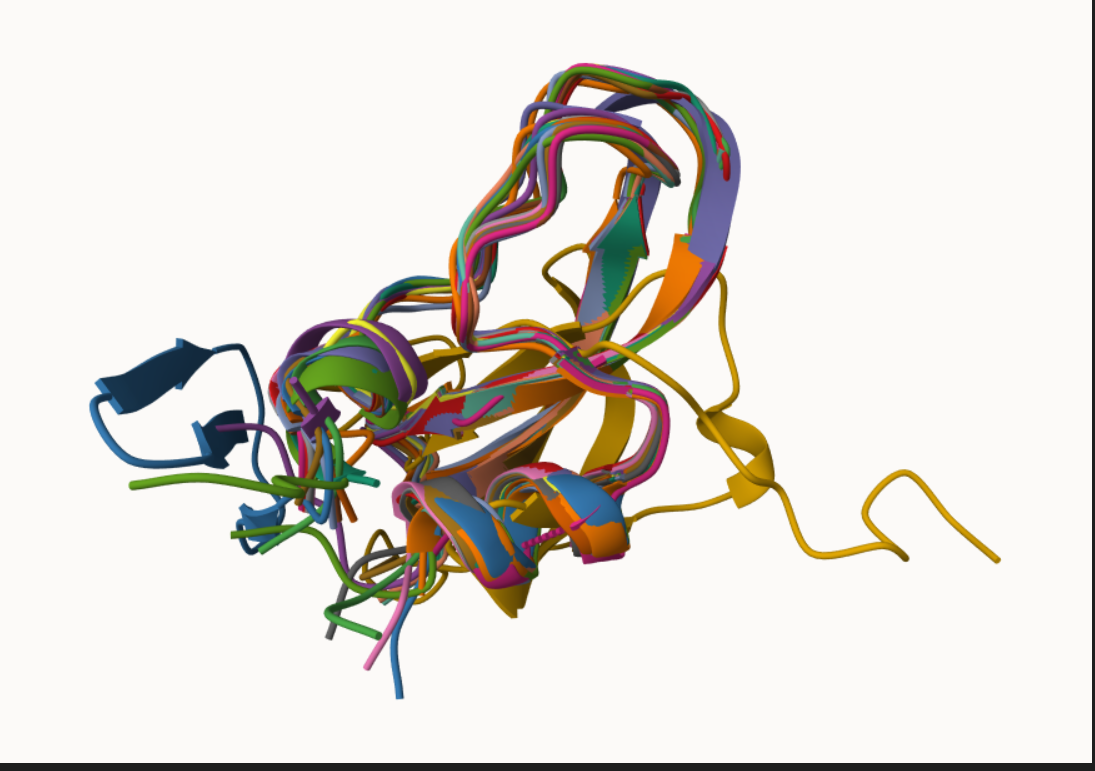